In [201]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import pickle

In [202]:
!unzip "/content/archive (5).zip"

Archive:  /content/archive (5).zip
replace auto-mpg.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: auto-mpg.csv            


In [203]:
import os
folder_path = "graphs"
os.makedirs(folder_path, exist_ok=True)

In [204]:
df = pd.read_csv("/content/auto-mpg.csv")

In [205]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


## EDA

In [206]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB
None


In [207]:
print(df.describe())

              mpg   cylinders  displacement       weight  acceleration  \
count  398.000000  398.000000    398.000000   398.000000    398.000000   
mean    23.514573    5.454774    193.425879  2970.424623     15.568090   
std      7.815984    1.701004    104.269838   846.841774      2.757689   
min      9.000000    3.000000     68.000000  1613.000000      8.000000   
25%     17.500000    4.000000    104.250000  2223.750000     13.825000   
50%     23.000000    4.000000    148.500000  2803.500000     15.500000   
75%     29.000000    8.000000    262.000000  3608.000000     17.175000   
max     46.600000    8.000000    455.000000  5140.000000     24.800000   

       model year      origin  
count  398.000000  398.000000  
mean    76.010050    1.572864  
std      3.697627    0.802055  
min     70.000000    1.000000  
25%     73.000000    1.000000  
50%     76.000000    1.000000  
75%     79.000000    2.000000  
max     82.000000    3.000000  


In [208]:
print(df.isnull().sum())

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64


In [209]:
df.replace('?', np.nan, inplace=True)


In [210]:
df['horsepower'] = df['horsepower'].astype(float)

In [211]:
df['horsepower'].fillna(df['horsepower'].mean(), inplace=True)

/tmp/ipykernel_1685/2571313987.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horsepower'].fillna(df['horsepower'].mean(), inplace=True)


## Visualizations

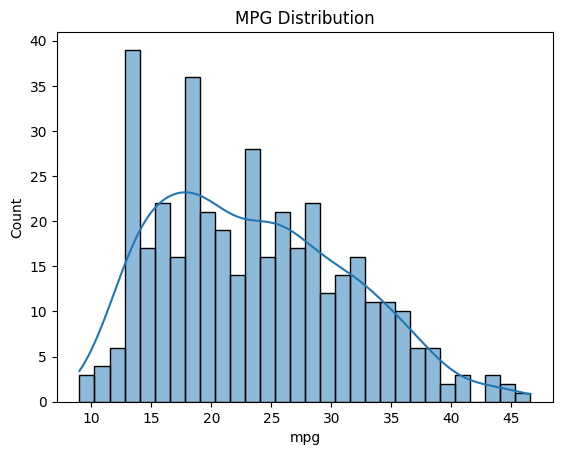

In [212]:
# MPG Distribution
plt.figure()
sns.histplot(df['mpg'], bins=30, kde=True)
plt.title("MPG Distribution")
plt.savefig("/content/graphs/MPG Distribution.png")  # save
plt.show()                      # notebook me display
plt.close()


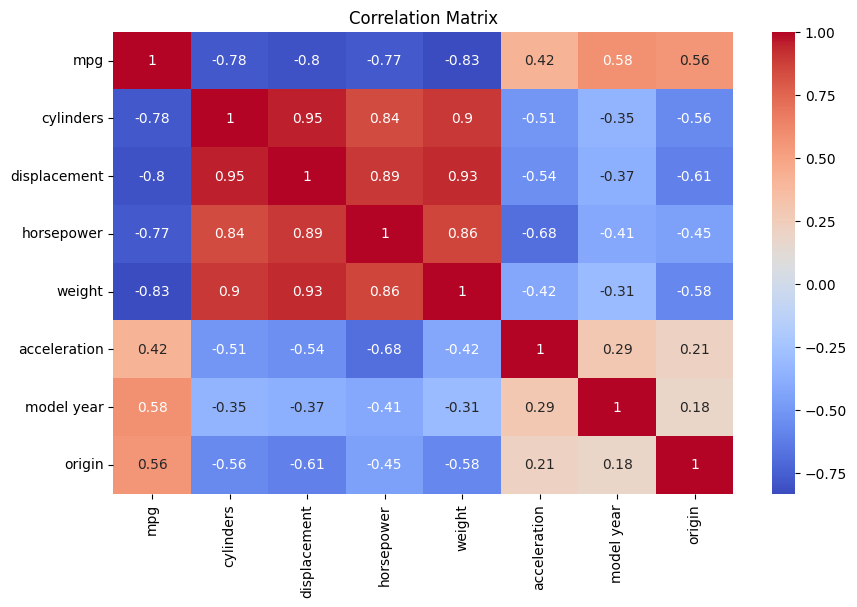

In [213]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.savefig("/content/graphs/Correlation Matrix.png")  # save
plt.show()                      # notebook me display
plt.close()

In [214]:
X = df.drop(['mpg', 'car name'], axis=1)
y = df['mpg']

In [215]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

## FEATURE SCALING

In [216]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

## MODELS

In [217]:
# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [218]:
# Model 2: Decision Tree
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

In [219]:
# Model 3: Random Forest
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

## MODEL COMPARISON

In [220]:
from sklearn.metrics import r2_score

print("Linear Regression R2:", r2_score(y_test, lr_pred))
print("Decision Tree R2:", r2_score(y_test, dt_pred))
print("Random Forest R2:", r2_score(y_test, rf_pred))

Linear Regression R2: 0.8538203870200513
Decision Tree R2: 0.7841651792645148
Random Forest R2: 0.8878927609261906


In [221]:
best_model = rf

In [222]:
print(model)

RandomForestRegressor()


In [223]:
from sklearn.metrics import r2_score

# Test prediction
test_r2 = r2_score(y_test, rf_pred)

# Validation prediction
val_pred = rf.predict(X_val)
val_r2 = r2_score(y_val, val_pred)

print("Test R2 Score:", test_r2)
print("Validation R2 Score:", val_r2)

Test R2 Score: 0.8878927609261906
Validation R2 Score: 0.883561426573148


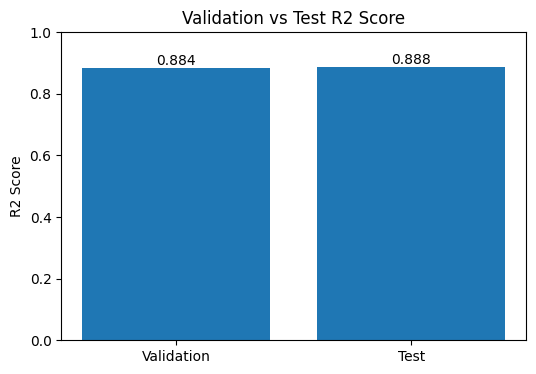

In [224]:
models = ["Validation", "Test"]
scores = [val_r2, test_r2]

plt.figure(figsize=(6,4))
plt.bar(models, scores)
plt.ylim(0, 1)
plt.title("Validation vs Test R2 Score")
plt.ylabel("R2 Score")

for i, v in enumerate(scores):
    plt.text(i, v + 0.01, str(round(v, 3)), ha='center')

plt.savefig("/content/graphs/validation_vs_test_r2.png")
plt.show()

In [225]:
pickle.dump(best_model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("Model & Scaler saved!")

Model & Scaler saved!


In [226]:
model = pickle.load(open("model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))

In [231]:
!pip install streamlit pyngrok

In [232]:
%%writefile app.py
import streamlit as st
import numpy as np
import pickle

# Load model + scaler
model = pickle.load(open("model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))

# ---------------- UI CONFIG ----------------
st.set_page_config(page_title="MPG Predictor", layout="wide")

# Background CSS (Car theme + dark glass effect)
st.markdown("""
<style>
.stApp {
    background-image: url("https://images.unsplash.com/photo-1503376780353-7e6692767b70");
    background-size: cover;
    background-attachment: fixed;
}

.main {
    background: rgba(0,0,0,0.65);
    padding: 20px;
    border-radius: 20px;
    color: white;
}

h1 {
    text-align: center;
    color: #00d4ff;
    font-size: 40px;
}

.stButton>button {
    background: linear-gradient(90deg, #00c6ff, #0072ff);
    color: white;
    font-size: 18px;
    border-radius: 10px;
    padding: 10px;
}
label {
    color: #4169E1 !important;
    font-weight: 600 !important;
    font-size: 35px !important;
}
.stNumberInput input {
    background-color: #1e1e1e !important;
    color: white !important;
    border-radius: 8px !important;
    border: 1px solid #555 !important;
}
.stNumberInput input:focus {
    border: 1px solid #FFD700 !important;
    box-shadow: 0px 0px 5px #FFD700 !important;
}
</style>
""", unsafe_allow_html=True)

# ---------------- TITLE ----------------
st.title("🚗 MPG PREDICTION DASHBOARD")

st.write("Enter car specifications below to predict fuel efficiency")

# ---------------- INPUTS ----------------
col1, col2 = st.columns(2)

with col1:
    cylinders = st.number_input("Cylinders", 3, 12, 6)
    displacement = st.number_input("Displacement", 0.0, 500.0, 150.0)
    horsepower = st.number_input("Horsepower", 0.0, 300.0, 90.0)
    weight = st.number_input("Weight", 0.0, 6000.0, 3000.0)

with col2:
    acceleration = st.number_input("Acceleration", 0.0, 30.0, 10.0)
    model_year = st.number_input("Model Year", 70, 100, 85)
    origin = st.number_input("Origin", 1, 3, 1)

# ---------------- PREDICT ----------------
if st.button("🚀 Predict MPG"):

    input_data = np.array([[cylinders, displacement, horsepower, weight,
                            acceleration, model_year, origin]])

    input_scaled = scaler.transform(input_data)
    prediction = model.predict(input_scaled)

    st.success(f"🚗 Predicted MPG: {prediction[0]:.2f}")

Overwriting app.py


In [233]:
from pyngrok import ngrok

ngrok.set_auth_token("3Cn4yQnzHrmJGFl1UG5qyXCSHOe_7hvG8x8fBBWdLTvdP8LcP")

In [234]:
from pyngrok import ngrok
import os

# open tunnel
public_url = ngrok.connect(8501)
print("Open this link:", public_url)

# run streamlit
os.system("streamlit run app.py")

Open this link: NgrokTunnel: "https://gong-bath-reviving.ngrok-free.dev" -> "http://localhost:8501"


2

In [236]:
import shutil

shutil.make_archive("project", "zip", ".")

'/content/project.zip'

In [237]:
from google.colab import files
files.download("project.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>